Сделано с асгардархеей.

In [1]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00


In [12]:
from Bio import SeqIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

records = list(SeqIO.parse("gen.fna", "fasta"))
print(f"Находим {len(records)} последовательностей в файле")

seq = ""
for record in records:
    seq += str(record.seq).upper()

print(f"Полная длина: {len(seq)}")

nucleotides = ['A', 'C', 'G', 'T']

dinucleotide_counts = {i+j: 0 for i in nucleotides for j in nucleotides}

for i in range(len(seq) - 1):
    dinucl = seq[i:i+2]
    if dinucl in dinucleotide_counts:
        dinucleotide_counts[dinucl] += 1

transition_matrix = np.zeros((4, 4))

for i, char_i in enumerate(nucleotides):
    row_sum = 0
    for j, char_j in enumerate(nucleotides):
        count = dinucleotide_counts[char_i + char_j]
        transition_matrix[i, j] = count
        row_sum += count

    if row_sum > 0:
        transition_matrix[i, :] /= row_sum

df_tm = pd.DataFrame(transition_matrix, index=nucleotides, columns=nucleotides)
print("\nМатрица переходов (P):")
print(df_tm)

row_sums = transition_matrix.sum(axis=1)
print(f"\nСуммы строк (должны быть 1.0): {row_sums}")

eigenvalues, eigenvectors = np.linalg.eig(transition_matrix.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
stationary = np.real(eigenvectors[:, idx])
stationary = stationary / stationary.sum()

print("\nСтационарное распределение (π):")
for n, val in zip(nucleotides, stationary):
    print(f"{n}: {val:.4f}")

observed_freqs = {n: seq.count(n) / len(seq) for n in nucleotides}
print("\nНаблюдаемые частоты нуклеотидов:")
for n in nucleotides:
    print(f"{n}: {observed_freqs[n]:.4f}")

Находим 295 последовательностей в файле
Полная длина: 1827468

Матрица переходов (P):
          A         C         G         T
A  0.365928  0.136469  0.175304  0.322299
C  0.348024  0.180313  0.141289  0.330373
G  0.362255  0.202829  0.179245  0.255671
T  0.258470  0.192450  0.183766  0.365314

Суммы строк (должны быть 1.0): [1. 1. 1. 1.]

Стационарное распределение (π):
A: 0.3271
C: 0.1738
G: 0.1728
T: 0.3262

Наблюдаемые частоты нуклеотидов:
A: 0.3271
C: 0.1738
G: 0.1728
T: 0.3262


Процесс сходимости матрицы P^k:

Матрица P^2:
        A       C       G       T
A  0.3282  0.1721  0.1741  0.3256
C  0.3267  0.1722  0.1725  0.3286
G  0.3342  0.1716  0.1713  0.3230
T  0.3226  0.1776  0.1726  0.3273

Матрица P^5:
        A       C       G       T
A  0.3271  0.1738  0.1728  0.3262
C  0.3271  0.1738  0.1728  0.3262
G  0.3271  0.1738  0.1728  0.3262
T  0.3271  0.1738  0.1728  0.3262

Матрица P^10:
        A       C       G       T
A  0.3271  0.1738  0.1728  0.3262
C  0.3271  0.1738  0.1728  0.3262
G  0.3271  0.1738  0.1728  0.3262
T  0.3271  0.1738  0.1728  0.3262

Матрица P^50:
        A       C       G       T
A  0.3271  0.1738  0.1728  0.3262
C  0.3271  0.1738  0.1728  0.3262
G  0.3271  0.1738  0.1728  0.3262
T  0.3271  0.1738  0.1728  0.3262

Матрица P^100:
        A       C       G       T
A  0.3271  0.1738  0.1728  0.3262
C  0.3271  0.1738  0.1728  0.3262
G  0.3271  0.1738  0.1728  0.3262
T  0.3271  0.1738  0.1728  0.3262

Матрица P^1000:
        A       C       G  

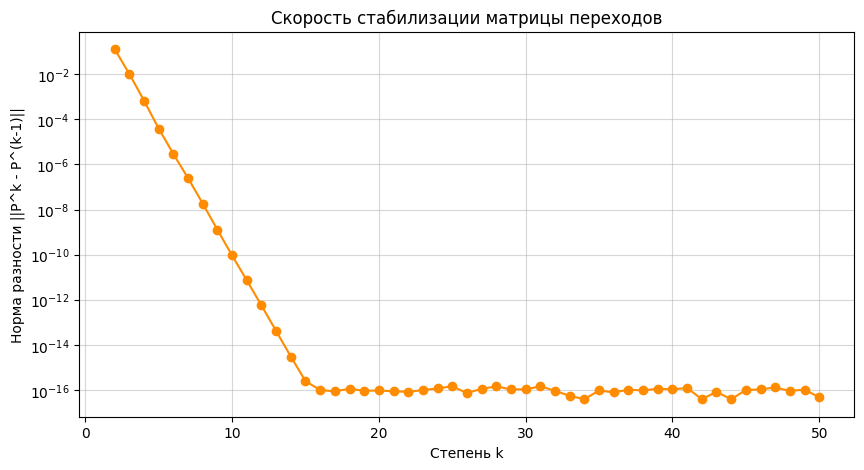


Стационарное распределение pi (аналитическое):
{'A': np.float64(0.3271), 'C': np.float64(0.1738), 'G': np.float64(0.1728), 'T': np.float64(0.3262)}
Строка матрицы P^1000:
{'A': np.float64(0.3271), 'C': np.float64(0.1738), 'G': np.float64(0.1728), 'T': np.float64(0.3262)}

Разница между строкой P^1000 и вектором pi: 7.04e-15


In [13]:
#6
P = df_tm
nucleotides = ['A', 'C', 'G', 'T']
ks = [2, 5, 10, 50, 100, 1000]

print("Процесс сходимости матрицы P^k:")
for k in ks:
    Pk = np.linalg.matrix_power(P, k)
    print(f"\nМатрица P^{k}:")
    print(pd.DataFrame(Pk, index=nucleotides, columns=nucleotides).round(4))

diff_norms = []
k_range = range(2, 51)

P_prev = P.copy()
for k in k_range:
    P_curr = np.linalg.matrix_power(P, k)
    norm = np.linalg.norm(P_curr - P_prev, ord='fro')
    diff_norms.append(norm)
    P_prev = P_curr

plt.figure(figsize=(10, 5))
plt.plot(k_range, diff_norms, marker='o', linestyle='-', color='darkorange')
plt.yscale('log')
plt.title("Скорость стабилизации матрицы переходов")
plt.xlabel("Степень k")
plt.ylabel("Норма разности ||P^k - P^(k-1)||")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()

print("\nСтационарное распределение pi (аналитическое):")
print(dict(zip(nucleotides, pi.round(4))))

last_Pk_row = np.linalg.matrix_power(P, 1000)[0]
print("Строка матрицы P^1000:")
print(dict(zip(nucleotides, last_Pk_row.round(4))))

diff = np.linalg.norm(pi - last_Pk_row)
print(f"\nРазница между строкой P^1000 и вектором pi: {diff:.2e}")